# Deployment 4 — the duty-cycled broadband floor (17–20 July 2025)

Characterises a broadband noise floor that switches off periodically, and measures
its level, timing, spectrum and rotation dependence.

**This notebook describes measurements, not conclusions.** It started from arp's
`EIGSEP_data_explore_v004_noise_dropout.ipynb`, which catalogued 19 "noise dropout"
events by eye and suspected they were our own RFI quieting rather than a receiver
effect. What follows tests that against the housekeeping telemetry and the full
5-day record.

| | |
|---|---|
| **Input** | `cache_dropout_{metadata,passA,passB}.npz` beside this notebook; raw `corr_*.h5` only if a cache is missing |
| **Produces** | 8 figures, an event census, the floor spectrum per antenna |
| **Runtime** | ~2 min with caches present; ~20 min if they must be rebuilt from 30 GB of raw files |

The caches make the three full-deployment passes (873 files each) cheap. Delete a
cache to force its rebuild.

## Two things to know before reading any figure

- **Correlator key 0 is viv2, whose front-end is dead** — roughly 37 dB low on both
  polarisations, with no comb visible. It appears in several figures below as a flat
  trace. That flatness is a dead receiver, not a quiet antenna, and it cannot be
  used as a control or as evidence about geometry.
- **The antennas are ~100 m apart, not metres.** The suspended bowtie and the ground
  Vivaldis are separated by roughly the site baseline. Earlier descriptions of these
  measurements said "metres apart", which is wrong and changes how a ratio between
  antennas should be read.

Section 8 references the emitter to the received calibration comb, which cancels
receiver gain and is the comparison that survives both points above.

In [1]:
import glob
import json
import warnings
from datetime import datetime
from zoneinfo import ZoneInfo

warnings.filterwarnings("ignore", message="Mean of empty slice")

import h5py
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter

MTN = ZoneInfo("America/Denver")
DATA_DIR = "../../../data/deployment4/corr_data"
HHMM = mdates.DateFormatter("%H:%M", tz=MTN)

# suspended bowtie: key '4' until the input swap on Jul 18 evening, key '2' after
SWAP = datetime(2025, 7, 18, 18, 0, tzinfo=MTN).timestamp()


def dnum(t):
    if np.ndim(t) == 0:
        return mdates.date2num(datetime.fromtimestamp(t, tz=MTN))
    return np.array([mdates.date2num(datetime.fromtimestamp(x, tz=MTN)) for x in np.asarray(t)])


def loc(t, fmt="%a %m-%d %H:%M:%S"):
    return datetime.fromtimestamp(t, tz=MTN).strftime(fmt)


def quat_to_euler(q):
    i, j, k, r = q.T
    yaw = np.degrees(np.arctan2(2 * (r * k + i * j), 1 - 2 * (j * j + k * k)))
    pitch = np.degrees(np.arcsin(np.clip(2 * (r * j - k * i), -1, 1)))
    roll = np.degrees(np.arctan2(2 * (r * i + j * k), 1 - 2 * (i * i + j * j)))
    return yaw, pitch, roll


def antenna_mask(times, sw_t, sw_s, guard=5.0):
    # sw_state == 0 (antenna), away from switch transitions
    ix = np.clip(np.searchsorted(sw_t, times, side="right") - 1, 0, len(sw_t) - 1)
    ant = sw_s[ix] == 0
    chg_t = sw_t[1:][np.diff(sw_s) != 0]
    j = np.searchsorted(chg_t, times)
    for off in (-1, 0):
        jj = np.clip(j + off, 0, len(chg_t) - 1)
        ant &= np.abs(times - chg_t[jj]) > guard
    return ant

In [2]:
%matplotlib inline

## arp's by-eye event list

19 `(start, end)` unix times copied verbatim from the v004 notebook, used here only
as a recall check on the automated detector. First 6: Fri 18 Jul 02:19–08:45 MDT;
last 13: Sun 20 Jul 02:05–08:54 MDT — both overnight blocks with the rig parked.
Durations cluster tightly near 240 s.

In [3]:
ARP_DROPOUTS = [
    (1752826741 - 4, 1752826741 + 240), (1752829296 - 4, 1752829296 + 239),
    (1752836820 - 4, 1752836820 + 240), (1752839293 - 4, 1752839293 + 244),
    (1752847809 - 4, 1752847809 + 239), (1752849929 - 4, 1752849929 + 239),
    (1752998738 - 4, 1752998738 + 239), (1753002924 - 4, 1753002924 + 239),
    (1753006892 - 4, 1753006892 + 266), (1753008681 - 4, 1753008681 + 239),
    (1753010172 - 4, 1753010172 + 240), (1753011706 - 4, 1753011706 + 257),
    (1753013096 - 4, 1753013096 + 240), (1753014466 - 4, 1753014466 + 240),
    (1753016215 - 4, 1753016215 + 240), (1753017894 - 4, 1753017894 + 239),
    (1753019562 - 4, 1753019562 + 248), (1753021191 - 4, 1753021191 + 239),
    (1753023264 - 4, 1753023264 + 241),
]
print(f"{len(ARP_DROPOUTS)} events; first {loc(ARP_DROPOUTS[0][0])}, last {loc(ARP_DROPOUTS[-1][0])}")

19 events; first Fri 07-18 02:18:57, last Sun 07-20 08:54:20


## Housekeeping telemetry

One pass over all files collecting five metadata streams. The streams republish the
*most recent report* at ~1 Hz, so a frozen payload carrying fresh timestamps means
the sensor is genuinely reporting a constant value rather than having stopped.

The motor stream is the exception: a single stale record from 11 Jul repeated for
the whole deployment. The motor controller published no status during observations,
so the IMUs are the only motion record available.

In [4]:
CACHE_META = "cache_dropout_metadata.npz"
try:
    _z = np.load(CACHE_META)
    sw_t, sw_s = _z["sw_t"], _z["sw_s"]
    pan_t, pan_q = _z["pan_t"], _z["pan_q"]
    ant_t, ant_q = _z["ant_t"], _z["ant_q"]
    mot_t, mot_v = _z["mot_t"], _z["mot_v"]
    tc_t, tc_v = _z["tc_t"], _z["tc_v"]
    print("loaded", CACHE_META)
except FileNotFoundError:
    SW, PAN, ANT, MOT, TC = [], [], [], [], []
    nbad = 0
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "metadata" not in f:
                    continue
                md_ = f["metadata"]

                def grab(key):
                    if key not in md_ or f"{key}_ts" not in md_:
                        return [], []
                    recs = json.loads(md_[key][()])
                    ts = [datetime.fromisoformat(s).timestamp() for s in json.loads(md_[f"{key}_ts"][()])]
                    return recs, ts

                for r, s in zip(*grab("rfswitch")):
                    SW.append((s, r["sw_state"]))
                for r, s in zip(*grab("imu_panda")):
                    PAN.append((s, r["quat_i"], r["quat_j"], r["quat_k"], r["quat_real"]))
                for r, s in zip(*grab("imu_antenna")):
                    ANT.append((s, r["quat_i"], r["quat_j"], r["quat_k"], r["quat_real"]))
                for r, s in zip(*grab("motor")):
                    MOT.append((s, r["az_pos"], r["el_pos"], r["az_remaining_steps"], r["el_remaining_steps"]))
                for r, s in zip(*grab("tempctrl")):
                    TC.append((s, r.get("A_drive_level", 0), float(r.get("A_active", False)),
                               r.get("B_drive_level", 0), float(r.get("B_active", False))))
        except OSError:
            nbad += 1

    def uniq(rows):
        a = np.array(rows, float)
        _, ix = np.unique(a[:, 0], return_index=True)
        return a[ix]

    SW, PAN, ANT, MOT, TC = map(uniq, (SW, PAN, ANT, MOT, TC))
    sw_t, sw_s = SW[:, 0], SW[:, 1]
    pan_t, pan_q = PAN[:, 0], PAN[:, 1:]
    ant_t, ant_q = ANT[:, 0], ANT[:, 1:]
    mot_t, mot_v = MOT[:, 0], MOT[:, 1:]
    tc_t, tc_v = TC[:, 0], TC[:, 1:]
    np.savez(CACHE_META, sw_t=sw_t, sw_s=sw_s, pan_t=pan_t, pan_q=pan_q,
             ant_t=ant_t, ant_q=ant_q, mot_t=mot_t, mot_v=mot_v, tc_t=tc_t, tc_v=tc_v)
    print(f"scanned ({nbad} unreadable files skipped), wrote {CACHE_META}")

print(f"unique reports: rfswitch {len(sw_t)}, imu_panda {len(pan_t)}, imu_antenna {len(ant_t)}, "
      f"motor {len(mot_t)}, tempctrl {len(tc_t)}")
print(f"motor stream: {len(mot_t)} unique report(s); latest {loc(mot_t.max())} -> stale, unusable")
print(f"tempctrl: nonzero drive levels in {np.count_nonzero(tc_v[:, [0, 2]])} records, "
      f"active flags in {np.count_nonzero(tc_v[:, [1, 3]])} records -> controller idle all deployment")

loaded cache_dropout_metadata.npz
unique reports: rfswitch 172420, imu_panda 172464, imu_antenna 50281, motor 1, tempctrl 172462
motor stream: 1 unique report(s); latest Fri 07-11 03:08:38 -> stale, unusable
tempctrl: nonzero drive levels in 0 records, active flags in 0 records -> controller idle all deployment


## Figure 1 — the feature itself

Per-channel detrended waterfalls around three 20 Jul events, antenna-state
integrations only, with the 40–65 MHz band mean underneath. Dashed black and green
lines mark arp's start and end times.

In [5]:
W0 = datetime(2025, 7, 20, 4, 30, tzinfo=MTN).timestamp()
W1 = datetime(2025, 7, 20, 7, 45, tzinfo=MTN).timestamp()
T, D = [], {k: [] for k in ["0", "2", "3", "4"]}
freq = None
for fn in sorted(glob.glob(f"{DATA_DIR}/corr_20250720_*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[0] > W1 or t[-1] < W0:
                continue
            T.append(t)
            for k in D:
                D[k].append(f[f"data/{k}"][()].astype(np.float32))
            if freq is None:
                freq = np.array(json.loads(f["header/freqs"][()]))
    except OSError:
        continue
times_w = np.concatenate(T)
order = np.argsort(times_w)
times_w = times_w[order]
data_w = {k: np.concatenate(v)[order] for k, v in D.items()}
ant_w = antenna_mask(times_w, sw_t, sw_s)
nchan = freq.size
nontx = np.arange(nchan) % 16 != 0  # comb in every 16th channel
print(f"{len(times_w)} integrations {loc(times_w[0])} - {loc(times_w[-1])}, antenna state: {ant_w.sum()}")

11040 integrations Sun 07-20 04:28:50 - Sun 07-20 07:46:46, antenna state: 10315


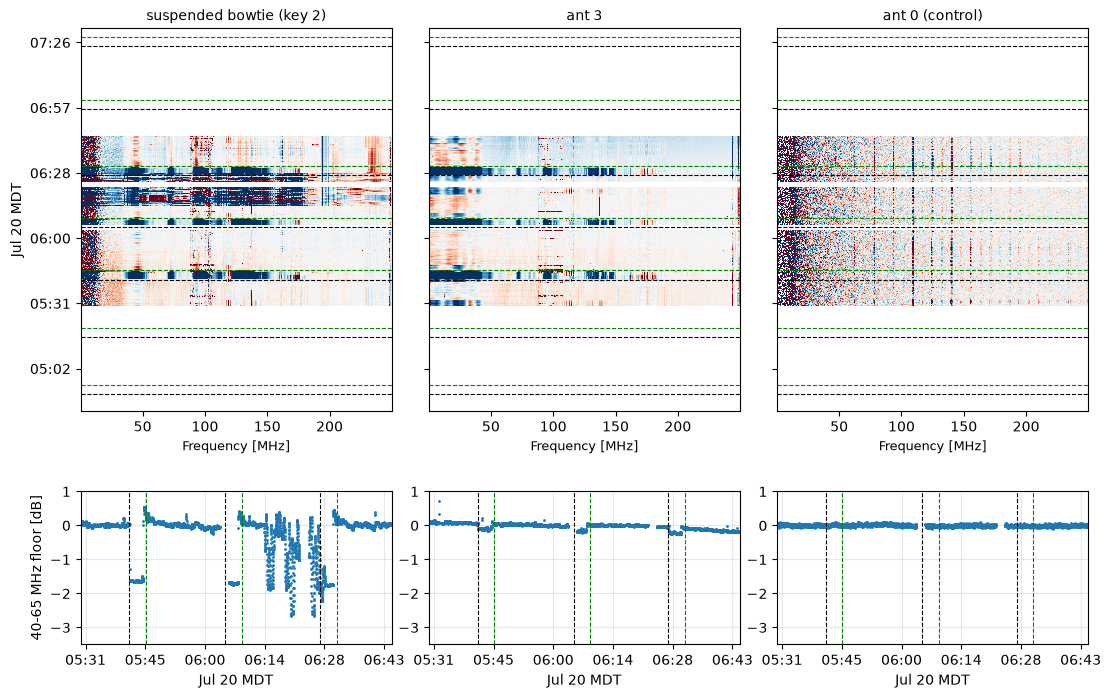

In [6]:
drops = [t0 + 4 for t0, _ in ARP_DROPOUTS if W0 < t0 < W1]
zoom = (times_w >= datetime(2025, 7, 20, 5, 30, tzinfo=MTN).timestamp()) & \
       (times_w <= datetime(2025, 7, 20, 6, 45, tzinfo=MTN).timestamp())
tz_ = times_w[zoom]
dz = dnum(tz_)

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1.2], hspace=0.30, wspace=0.12)
band_ql = nontx & (freq >= 40) & (freq <= 65)
for col, (k, name) in enumerate([("2", "suspended bowtie (key 2)"), ("3", "ant 3"), ("0", "ant 0 (control)")]):
    d = data_w[k][zoom].astype(float)
    d[~ant_w[zoom]] = np.nan
    med = np.nanmedian(d, axis=0)
    with np.errstate(all="ignore"):
        r = 10 * np.log10(np.abs(d / np.where(med > 0, med, 1)))
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(r[:, nontx], aspect="auto", origin="lower", interpolation="nearest",
              extent=[freq[nontx][0], freq[nontx][-1], dz[0], dz[-1]], vmin=-0.6, vmax=0.6, cmap="RdBu_r")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Frequency [MHz]", fontsize=9)
    for dd in drops:
        for x, c in [(dd, "k"), (dd + 240, "g")]:
            ax.axhline(dnum(x), color=c, lw=0.8, ls="--")
    if col == 0:
        ax.yaxis.set_major_formatter(HHMM)
        ax.set_ylabel("Jul 20 MDT")
    else:
        ax.set_yticklabels([])
    ax2 = fig.add_subplot(gs[1, col])
    ts = np.nanmean(d[:, band_ql], axis=1)
    with np.errstate(all="ignore"):
        ax2.plot(dz, 10 * np.log10(ts / np.nanmedian(ts)), ".", ms=2)
    for dd in drops:
        for x, c in [(dd, "k"), (dd + 240, "g")]:
            ax2.axvline(dnum(x), color=c, lw=0.8, ls="--")
    ax2.set_ylim(-3.5, 1)
    ax2.set_xlim(dz[0], dz[-1])
    ax2.xaxis.set_major_formatter(HHMM)
    ax2.grid(alpha=0.3)
    ax2.set_xlabel("Jul 20 MDT")
    if col == 0:
        ax2.set_ylabel("40-65 MHz floor [dB]")
plt.show()

**Figure 1.** Three 20 Jul events. Top row: per-channel detrended waterfalls for the
suspended bowtie (key 2), ant 3 and ant 0, non-comb channels, ±0.6 dB colour scale.
Bottom row: the 40–65 MHz band mean for each. The drops are square and flat-bottomed,
1–3 dB deep, and span the displayed band rather than a single feature. They are clear
on the bowtie, weaker on ant 3.

Ant 0 is flat — but it is viv2 with a dead front-end, so this panel shows a
non-functioning receiver, not a quiet antenna. It is not a control.

## Figure 2 — what changes, as a spectrum

Median spectrum inside the events against a local baseline taken from the same
window outside them. Plotted as a ratio in dB, per antenna.

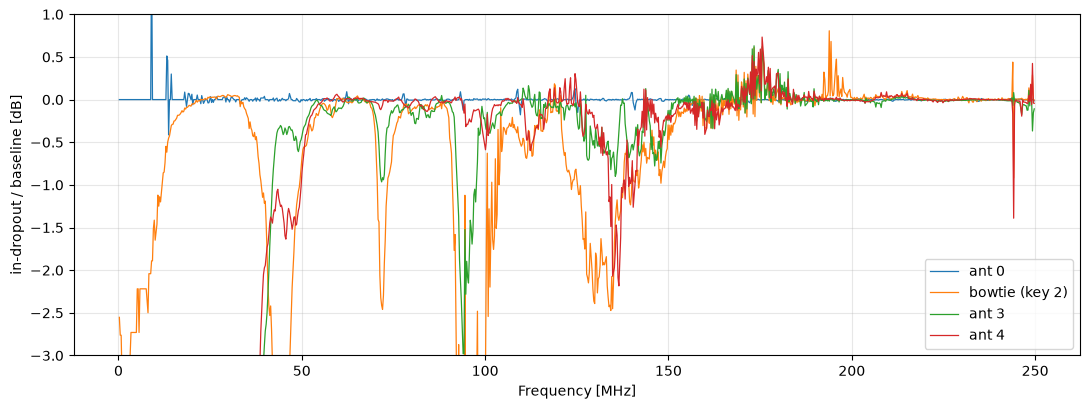

In [7]:
in_drop = np.zeros(len(times_w), bool)
for dd in drops:
    in_drop |= (times_w >= dd + 20) & (times_w <= dd + 220)
out_drop = ~in_drop.copy()
for dd in drops:
    out_drop &= ~((times_w >= dd - 60) & (times_w <= dd + 300))

fig, ax0 = plt.subplots(1, 1, figsize=(11, 4.2))
for k in ["0", "2", "3", "4"]:
    d = data_w[k]
    sp_in = np.nanmedian(np.where((ant_w & in_drop)[:, None], d, np.nan), axis=0)
    sp_out = np.nanmedian(np.where((ant_w & out_drop)[:, None], d, np.nan), axis=0)
    with np.errstate(all="ignore"):
        ratio = 10 * np.log10(sp_in / sp_out)
    lbl = "bowtie (key 2)" if k == "2" else f"ant {k}"
    ax0.plot(freq[nontx], ratio[nontx], lw=0.9, label=lbl)
ax0.set_ylabel("in-dropout / baseline [dB]")
ax0.set_ylim(-3, 1)
ax0.grid(alpha=0.3)
ax0.legend()
ax0.set_xlabel("Frequency [MHz]")
plt.tight_layout()
plt.show()

**Figure 2.** Median spectrum inside the events divided by the local baseline, per
antenna, non-comb channels. The component that switches is broadband across roughly
30–160 MHz, 1–3 dB deep on the bowtie and on ants 3/4, rather than confined to a line
or a narrow band. Ant 0 sits at zero for the reason given in Figure 1.

A previous version of this figure carried a second panel showing the same difference
in raw counts on a ±200 000 scale; it duplicated this panel and has been dropped.

### Comb stability and the narrowband lines

Two checks run on the same windows, printed rather than plotted.

The received calibration comb holds to ±0.1 dB on every antenna through the events.
That constrains two things at once: the comb transmit chain is not the component
switching, and receiver gain is stable, so no attenuator or receiver state change is
masquerading as a power drop.

The narrowband lines are tested **per event** rather than as one pooled median — the
lines wander slowly, so a single in/out median is biased. Neither the 152.59 MHz line
(channel 625) nor the 244.14 MHz line (channels 999/1000) changes consistently across
events, so whatever produces the broadband floor is not what produces the lines.

In [8]:
comb = np.arange(16, nchan, 16)
print(f"{'ant':>14} {'comb 30-80':>11} {'comb 80-150':>12} {'comb 150-240':>13} "
      f"{'ch625/event':>12} {'ch999+1000/event':>17}")
for k in ["0", "2", "3", "4"]:
    d = data_w[k].astype(float)
    d[(d < 0) | (d > 1.5e9)] = np.nan  # int32-wrap pixels
    d[~ant_w] = np.nan
    sp_in = np.nanmedian(np.where(in_drop[:, None], d, np.nan), axis=0)
    sp_out = np.nanmedian(np.where(out_drop[:, None], d, np.nan), axis=0)
    with np.errstate(all="ignore"):
        r = 10 * np.log10(sp_in / sp_out)
    row = [np.nanmedian(r[comb[(freq[comb] >= f0) & (freq[comb] < f1)]]) for f0, f1 in
           [(30, 80), (80, 150), (150, 240)]]
    # per-event line changes: median over events of in/near-baseline ratio
    deltas = {}
    for name, chs in [("625", [625]), ("244", [999, 1000])]:
        line = np.nansum(d[:, chs], axis=1)
        line[line <= 0] = np.nan
        dl = []
        for dd in drops:
            m_in = (times_w >= dd + 20) & (times_w <= dd + 220)
            m_out = ((times_w >= dd - 300) & (times_w <= dd - 60)) | \
                    ((times_w >= dd + 300) & (times_w <= dd + 540))
            with np.errstate(all="ignore"):
                dl.append(10 * np.log10(np.nanmedian(line[m_in]) / np.nanmedian(line[m_out])))
        deltas[name] = np.nanmedian(dl)
    lbl = "bowtie (key 2)" if k == "2" else f"ant {k}"
    print(f"{lbl:>14} {row[0]:>+10.3f} {row[1]:>+11.3f} {row[2]:>+12.3f} "
          f"{deltas['625']:>+11.2f} {deltas['244']:>+16.2f}")

           ant  comb 30-80  comb 80-150  comb 150-240  ch625/event  ch999+1000/event


         ant 0     +0.000      -0.009       -0.001       +0.00            -0.00


bowtie (key 2)     -0.015      -0.051       +0.033       -0.12            -0.01


         ant 3     -0.080      -0.057       +0.064       +0.03            -0.00


         ant 4     -0.025      -0.002       +0.037       -0.07            -0.16


## Was anything moving during the events?

A direct test of the rotation reading of arp's hypothesis. Both IMU streams report at
~1 Hz with fresh timestamps throughout; their *values* change only during the daytime
work and beam-mapping sessions.

All 19 of arp's events fall in periods where both IMUs are frozen and the motor server
is silent — the rig was stationary. Whatever the events are, they are not caused by the
platform moving.

In [9]:
def activity_periods(t, v, gap=600):
    chg = np.nonzero(np.any(np.diff(v, axis=0) != 0, axis=1))[0] + 1
    if len(chg) == 0:
        return []
    ct = t[chg]
    breaks = np.nonzero(np.diff(ct) > gap)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends = np.concatenate([breaks, [len(ct) - 1]])
    return [(ct[s], ct[e], e - s + 1) for s, e in zip(starts, ends)]

for name, (t_, v_) in {"imu_panda": (pan_t, pan_q), "imu_antenna": (ant_t, ant_q)}.items():
    print(f"{name} value-change periods:")
    for s, e, n in activity_periods(t_, v_):
        print(f"   {loc(s, '%a %m-%d %H:%M')} - {loc(e, '%H:%M')}  ({n} changes)")

nmoving = 0
for t0, t1 in ARP_DROPOUTS:
    m = (pan_t >= t0 - 60) & (pan_t <= t1 + 60)
    nmoving += np.any(np.diff(pan_q[m], axis=0) != 0)
print(f"\narp events with any imu_panda value change within +-60 s: {nmoving}/{len(ARP_DROPOUTS)}")

imu_panda value-change periods:
   Thu 07-17 16:40 - 17:32  (2904 changes)
   Thu 07-17 19:42 - 22:27  (9154 changes)
   Fri 07-18 09:45 - 09:49  (22 changes)
   Fri 07-18 13:03 - 13:24  (996 changes)
   Sat 07-19 11:09 - 13:20  (7021 changes)
imu_antenna value-change periods:
   Thu 07-17 16:40 - 16:44  (231 changes)
   Thu 07-17 19:42 - 19:47  (287 changes)

arp events with any imu_panda value change within +-60 s: 0/19


## Figure 3 — full-deployment census

Detector: band mean over the two deepest dip bands (95–110 and 125–150 MHz, non-comb
channels) on the bowtie — key 4 before the input swap, key 2 after — detrended by a
35-minute running median over antenna-state samples, threshold −0.7 dB, runs merged
across gaps under 2 min, durations kept between 2 and 10 min.

Two limits on the counts. The comb transmitter's own power cycling modulates the same
band at the ±0.3 dB level, which is why the threshold is conservative. And during work
hours the floor moves for unrelated reasons, so **daytime counts are upper limits**.

The detector recovers 15 of arp's 19 by-eye events; the misses sit at threshold or are
interrupted by cal-cycle masking.

In [10]:
CACHE_A = "cache_dropout_passA.npz"
try:
    _z = np.load(CACHE_A)
    times_c, bow2, bow4 = _z["times_c"], _z["bow2"], _z["bow4"]
    print("loaded", CACHE_A)
except FileNotFoundError:
    dip = nontx & (((freq >= 95) & (freq <= 110)) | ((freq >= 125) & (freq <= 150)))
    T, B2, B4 = [], [], []
    nbad = 0
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "header" not in f or "times" not in f["header"]:
                    nbad += 1
                    continue
                t = np.array(json.loads(f["header/times"][()]))
                b2 = f["data/2"][()].astype(np.float32)[:, dip].mean(axis=1)
                b4 = f["data/4"][()].astype(np.float32)[:, dip].mean(axis=1)
            T.append(t), B2.append(b2), B4.append(b4)
        except OSError:
            nbad += 1
    times_c = np.concatenate(T)
    order = np.argsort(times_c)
    times_c, bow2, bow4 = times_c[order], np.concatenate(B2)[order], np.concatenate(B4)[order]
    ok = times_c > 1.7e9  # a handful of integrations carry zeroed timestamps
    times_c, bow2, bow4 = times_c[ok], bow2[ok], bow4[ok]
    np.savez(CACHE_A, times_c=times_c, bow2=bow2, bow4=bow4)
    print(f"scanned ({nbad} unreadable/incomplete files skipped), wrote {CACHE_A}")

ant_c = antenna_mask(times_c, sw_t, sw_s)
bow = np.where(times_c < SWAP, bow4, bow2).astype(float)
bow[~ant_c] = np.nan
good = np.isfinite(bow)
fi = np.interp(times_c, times_c[good], bow[good])
base = median_filter(fi, size=int(35 * 60 / 1.07), mode="nearest")
with np.errstate(all="ignore"):
    r_det = 10 * np.log10(fi / base)
r_det[~good] = np.nan

low = np.nan_to_num(r_det) < -0.7
dd_ = np.diff(low.astype(int))
starts, ends = np.nonzero(dd_ == 1)[0] + 1, np.nonzero(dd_ == -1)[0] + 1
runs = []
for s, e in zip(starts, ends):
    if runs and times_c[s] - times_c[runs[-1][1]] < 120:
        runs[-1][1] = e
    else:
        runs.append([s, e])
# depth = median of the below-threshold samples (the merged span includes masked gaps)
events = np.array([(times_c[s], times_c[e] - times_c[s],
                    np.nanmedian(np.where(r_det[s:e] < -0.7, r_det[s:e], np.nan)))
                   for s, e in runs if 120 < times_c[e] - times_c[s] < 600])

hours = np.array([datetime.fromtimestamp(t, tz=MTN).hour + datetime.fromtimestamp(t, tz=MTN).minute / 60
                  for t in events[:, 0]])
is_night = (hours >= 20.5) | (hours <= 9.5)
matched = sum(bool(np.any(np.abs(events[:, 0] - t0) < 150)) for t0, _ in ARP_DROPOUTS)
gaps = np.diff(events[:, 0]) / 60
from collections import Counter
per_day = Counter(loc(t, "%a %m-%d") for t in events[:, 0])
print(f"{len(events)} events; per day: {dict(sorted(per_day.items(), key=lambda kv: kv[0][4:]))}")
print(f"{is_night.sum()} at night (20:30-09:30 MDT), {(~is_night).sum()} in work hours (daytime = upper limit)")
print(f"duration: median {np.median(events[:, 1]):.0f} s, 10-90%: "
      f"[{np.percentile(events[:, 1], 10):.0f}, {np.percentile(events[:, 1], 90):.0f}] s")
print(f"depth (dip band, below-threshold samples): median {np.nanmedian(events[:, 2]):.2f} dB")
print(f"gaps between events: median {np.median(gaps[gaps < 120]):.0f} min (of gaps < 2 h)")
print(f"arp events recovered: {matched}/{len(ARP_DROPOUTS)}")
# duty cycle over valid antenna-state samples only (data exist from Jul 15, telemetry from Jul 17)
in_ev = np.zeros(len(times_c), bool)
for t0, dur, _ in events:
    in_ev |= (times_c >= t0) & (times_c <= t0 + dur)
hrs_c = np.array([datetime.fromtimestamp(t, tz=MTN).hour + datetime.fromtimestamp(t, tz=MTN).minute / 60
                  for t in times_c])
night_c = (hrs_c >= 20.5) | (hrs_c <= 9.5)
print(f"fraction of antenna-state time in dropout (floor OFF): {in_ev[good].mean() * 100:.1f}% overall, "
      f"{in_ev[good & night_c].mean() * 100:.1f}% in night hours "
      f"-> the floor is PRESENT ~{100 - in_ev[good & night_c].mean() * 100:.0f}% of the time")

loaded cache_dropout_passA.npz
91 events; per day: {'Thu 07-17': 11, 'Fri 07-18': 28, 'Sat 07-19': 23, 'Sun 07-20': 29}
38 at night (20:30-09:30 MDT), 53 in work hours (daytime = upper limit)
duration: median 233 s, 10-90%: [140, 512] s
depth (dip band, below-threshold samples): median -1.12 dB
gaps between events: median 24 min (of gaps < 2 h)
arp events recovered: 15/19


fraction of antenna-state time in dropout (floor OFF): 12.1% overall, 10.7% in night hours -> the floor is PRESENT ~89% of the time


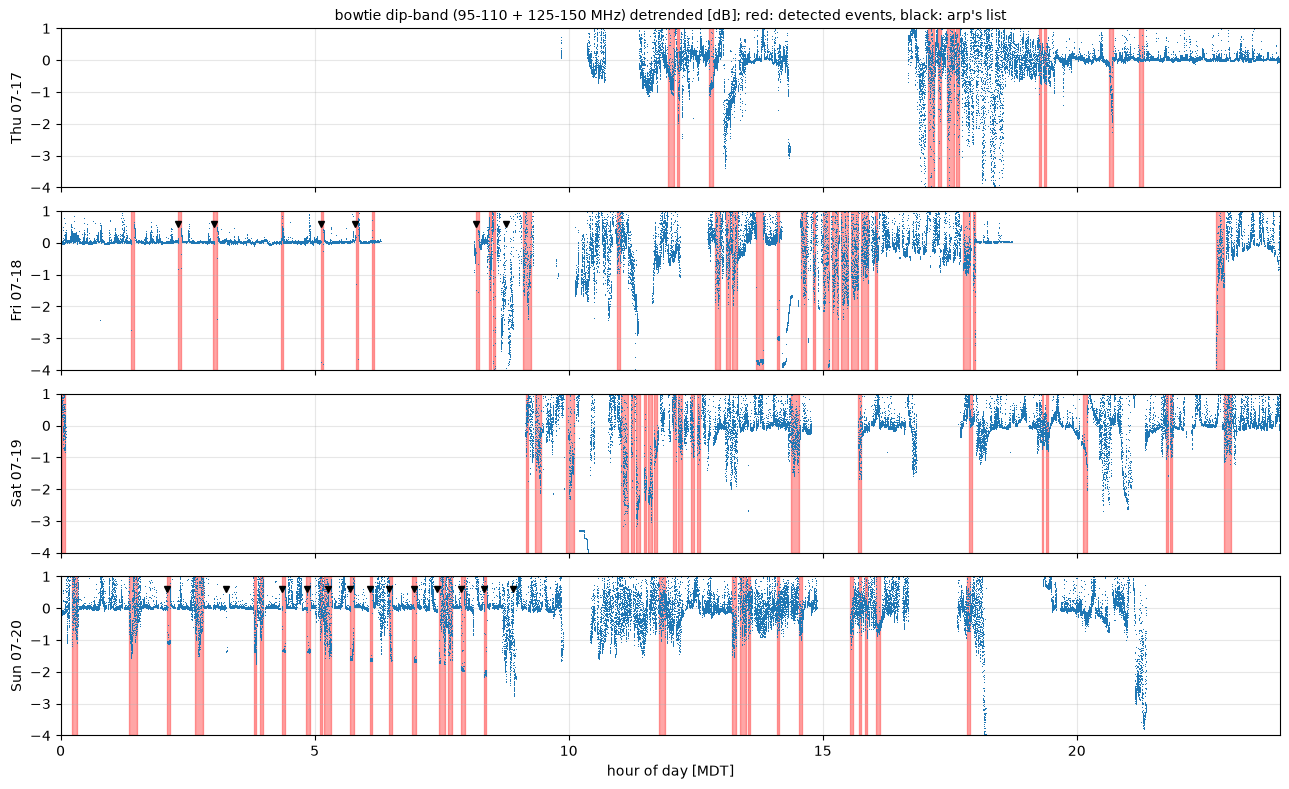

In [11]:
days = [datetime(2025, 7, d, 0, 0, tzinfo=MTN) for d in range(17, 21)]
fig, axes = plt.subplots(len(days), 1, figsize=(13, 8), sharex=True, sharey=True)
for ax, day in zip(axes, days):
    d0 = day.timestamp()
    m = (times_c >= d0) & (times_c < d0 + 86400)
    ax.plot((times_c[m] - d0) / 3600, r_det[m], ",", color="C0")
    for t0, dur, _ in events:
        if d0 <= t0 < d0 + 86400:
            ax.axvspan((t0 - d0) / 3600, (t0 + dur - d0) / 3600, color="r", alpha=0.35)
    for t0, _ in ARP_DROPOUTS:
        if d0 <= t0 < d0 + 86400:
            ax.plot((t0 - d0) / 3600, 0.6, "kv", ms=5)
    ax.set_ylabel(day.strftime("%a %m-%d"))
    ax.set_ylim(-4, 1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("hour of day [MDT]")
axes[-1].set_xlim(0, 24)
axes[0].set_title("bowtie dip-band (95-110 + 125-150 MHz) detrended [dB]; red: detected events, "
                  "black: arp's list", fontsize=10)
plt.tight_layout()
plt.show()

**Figure 3.** Detected events across the four full days, one row per day, plotted
against local time. Blue is the detrended band mean; red bands mark detected events;
black triangles are arp's by-eye list where it overlaps. Events occur throughout, day
and night, for the whole deployment — not only in the overnight blocks where they were
first noticed. Daytime counts are upper limits.

## Figure 4 — the level, as a fraction of total measured power

Night events only, which are clean of human activity. Each event is differenced
against its own ±9-minute local baseline, so sky drift and FM fading cannot
masquerade as floor power — a pooled in/out stack fails in exactly that way.

**What this quantity is and is not.** It expresses the floor as a fraction of *each
antenna's own total measured power*. That makes it a within-antenna quantity: it says
how much of what this receiver sees is the emitter. It is **not** a field-strength
comparison between antennas, because each antenna's bandpass, gain and sky coupling
divide out differently. Reading the between-antenna spread here as geometry is what
the gain-free version in Figure 7 is for.

loaded cache_dropout_passB.npz


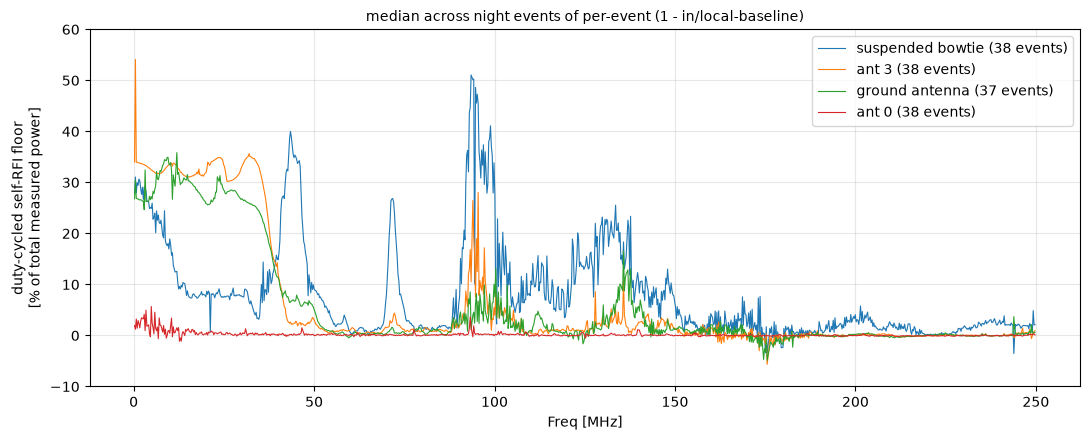

 bowtie 40-65 MHz: median   6.8%, peak  40.0% of total power
      3 40-65 MHz: median   1.4%, peak  11.9% of total power
      0 40-65 MHz: median   0.1%, peak   1.5% of total power
 bowtie 110-150 MHz: median  10.8%, peak  25.5% of total power
      3 110-150 MHz: median   1.4%, peak  10.7% of total power
      0 110-150 MHz: median   0.0%, peak   1.1% of total power


In [12]:
CACHE_B = "cache_dropout_passB.npz"
nev = events[is_night]
ev_t0, ev_t1 = nev[:, 0], nev[:, 0] + nev[:, 1]
all_t0, all_t1 = events[:, 0], events[:, 0] + events[:, 1]
PHYS = ["bowtie", "ground", "0", "3"]
nE = len(nev)
try:
    _z = np.load(CACHE_B)
    S_IN = {p: _z[f"sin_{p}"] for p in PHYS}
    S_OUT = {p: _z[f"sout_{p}"] for p in PHYS}
    C_IN = {p: _z[f"cin_{p}"] for p in PHYS}
    C_OUT = {p: _z[f"cout_{p}"] for p in PHYS}
    print("loaded", CACHE_B)
except FileNotFoundError:
    # per-event paired accumulation: each event gets its own local (+-9 min) baseline,
    # so sky drift and FM fading between epochs cannot masquerade as floor power
    S_IN = {p: np.zeros((nE, nchan)) for p in PHYS}
    S_OUT = {p: np.zeros((nE, nchan)) for p in PHYS}
    C_IN = {p: np.zeros((nE, nchan)) for p in PHYS}
    C_OUT = {p: np.zeros((nE, nchan)) for p in PHYS}
    for fn in sorted(glob.glob(f"{DATA_DIR}/corr_*.h5")):
        try:
            with h5py.File(fn, "r") as f:
                if "header" not in f or "times" not in f["header"]:
                    continue
                t = np.array(json.loads(f["header/times"][()]))
                if not np.any((t[-1] > ev_t0 - 600) & (t[0] < ev_t1 + 600)):
                    continue
                a = antenna_mask(t, sw_t, sw_s)
                near = np.zeros(len(t), bool)  # near ANY event (baseline exclusion)
                for t0, t1 in zip(all_t0, all_t1):
                    near |= (t >= t0 - 60) & (t <= t1 + 60)
                key_map = {"bowtie": "4", "ground": "2"} if t[0] < SWAP else {"bowtie": "2", "ground": "4"}
                key_map.update({"0": "0", "3": "3"})
                data_f = {}
                for ie in range(nE):
                    t0, t1 = ev_t0[ie], ev_t1[ie]
                    m_in = a & (t >= t0 + 20) & (t <= t1 - 20)
                    m_out = a & ~near & (((t >= t0 - 540) & (t < t0)) | ((t > t1) & (t <= t1 + 540)))
                    if not (m_in.any() or m_out.any()):
                        continue
                    for p, k in key_map.items():
                        if p not in data_f:
                            d = f[f"data/{k}"][()].astype(np.float64)
                            valid = (d >= 0) & (d < 1.5e9)  # int32-wrap pixels
                            data_f[p] = (np.where(valid, d, 0), valid)
                        d, valid = data_f[p]
                        S_IN[p][ie] += d[m_in].sum(axis=0)
                        C_IN[p][ie] += valid[m_in].sum(axis=0)
                        S_OUT[p][ie] += d[m_out].sum(axis=0)
                        C_OUT[p][ie] += valid[m_out].sum(axis=0)
        except OSError:
            continue
    np.savez(CACHE_B, **{f"sin_{p}": S_IN[p] for p in PHYS}, **{f"sout_{p}": S_OUT[p] for p in PHYS},
             **{f"cin_{p}": C_IN[p] for p in PHYS}, **{f"cout_{p}": C_OUT[p] for p in PHYS})
    print(f"accumulated {nE} night events, wrote {CACHE_B}")

# per-event fraction, then median across events with enough samples on both sides
FRAC = {}
for p in PHYS:
    with np.errstate(all="ignore"):
        fr = 1 - (S_IN[p] / C_IN[p]) / (S_OUT[p] / C_OUT[p])
    ok_ev = (C_IN[p].min(axis=1) >= 50) & (C_OUT[p].min(axis=1) >= 100)
    FRAC[p] = (np.nanmedian(fr[ok_ev], axis=0), ok_ev.sum())

fig, ax = plt.subplots(figsize=(11, 4.5))
for p, lbl in [("bowtie", "suspended bowtie"), ("3", "ant 3"), ("ground", "ground antenna"), ("0", "ant 0")]:
    frac, nok = FRAC[p]
    ax.plot(freq[nontx], 100 * frac[nontx], lw=0.8, label=f"{lbl} ({nok} events)")
ax.set_xlabel("Freq [MHz]")
ax.set_ylabel("duty-cycled self-RFI floor\n[% of total measured power]")
ax.set_ylim(-10, 60)
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("median across night events of per-event (1 - in/local-baseline)", fontsize=10)
plt.tight_layout()
plt.show()
for f0, f1 in [(40, 65), (110, 150)]:
    b = nontx & (freq >= f0) & (freq <= f1)
    for p in ["bowtie", "3", "0"]:
        frac, _ = FRAC[p]
        print(f"{p:>7} {f0}-{f1} MHz: median {100 * np.nanmedian(frac[b]):5.1f}%, "
              f"peak {100 * np.nanmax(frac[b]):5.1f}% of total power")

**Figure 4.** Stacked night events: the floor as a fraction of each antenna's own total
measured power. On the bowtie it runs ~7–11 % across 40–150 MHz with peaks near 40 %
at 40–65 MHz and ~25 % at 110–150 MHz. Ant 0 sits near 0.1 %, which is the dead
front-end again.

This is a within-antenna fraction. The spread between traces mixes real differences
with differences in bandpass, gain and sky coupling, so it does not localise the
source. Figure 7 is the gain-free version.

## Figures 5 and 6 — behaviour during a pitch raster

The automated pitch raster at the end of the Saturday beam-mapping session, 19 Jul
13:05–13:20: the platform sweeps pitch ±90° ten times while the **suspended bowtie
hangs stationary**.

Figure 5 shows the bowtie floor in two bands, the ant-3 floor, the platform pitch, and
the 244 MHz line, all on a common time axis. Figure 6 bins the floor against pitch.

The binned curve in Figure 6 underestimates the swing, because the modulation is not a
function of pitch alone.

In [13]:
R0 = datetime(2025, 7, 19, 12, 55, tzinfo=MTN).timestamp()
R1 = datetime(2025, 7, 19, 13, 25, tzinfo=MTN).timestamp()
T, D = [], {k: [] for k in ["2", "3"]}
for fn in sorted(glob.glob(f"{DATA_DIR}/corr_20250719_*.h5")):
    try:
        with h5py.File(fn, "r") as f:
            t = np.array(json.loads(f["header/times"][()]))
            if t[0] > R1 or t[-1] < R0:
                continue
            T.append(t)
            for k in D:
                D[k].append(f[f"data/{k}"][()].astype(np.float32))
    except OSError:
        continue
times_r = np.concatenate(T)
order = np.argsort(times_r)
times_r = times_r[order]
data_r = {k: np.concatenate(v)[order] for k, v in D.items()}
m = (times_r >= R0) & (times_r <= R1)
times_r = times_r[m]
data_r = {k: v[m] for k, v in data_r.items()}
ant_r = antenna_mask(times_r, sw_t, sw_s)
mi = (pan_t >= R0) & (pan_t <= R1)
yaw_r, pitch_r, roll_r = quat_to_euler(pan_q[mi])
pitch_i = np.interp(times_r, pan_t[mi], pitch_r)  # platform pitch at each integration
print(f"{len(times_r)} integrations, {mi.sum()} imu reports")

1673 integrations, 1670 imu reports


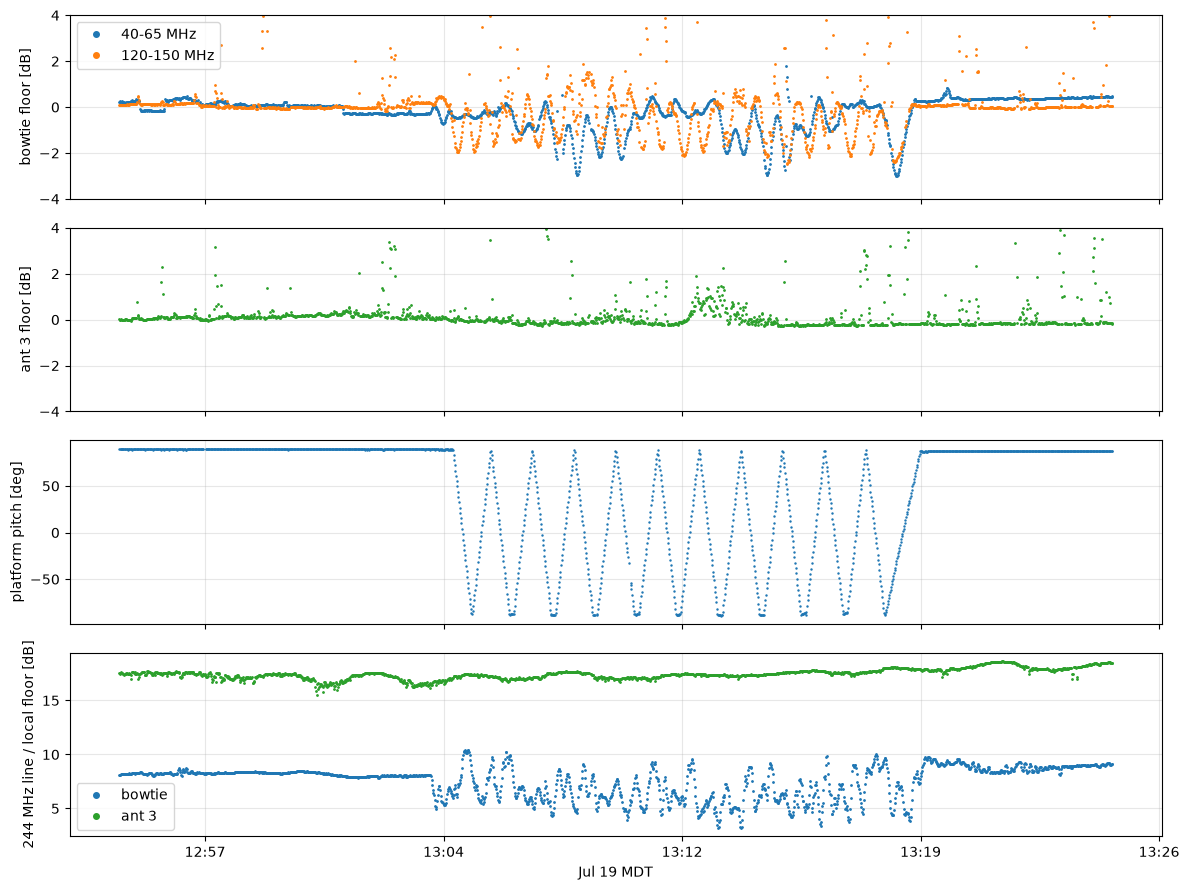

In [14]:
band1 = nontx & (freq >= 40) & (freq <= 65)
band2 = nontx & (freq >= 120) & (freq <= 150)
dr = dnum(times_r)
idr = dnum(pan_t[mi])

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
d2 = data_r["2"].astype(float)
d2[~ant_r] = np.nan
for bb, lbl in [(band1, "40-65 MHz"), (band2, "120-150 MHz")]:
    ts = np.nanmean(d2[:, bb], axis=1)
    with np.errstate(all="ignore"):
        axes[0].plot(dr, 10 * np.log10(ts / np.nanmedian(ts)), ".", ms=2, label=lbl)
axes[0].set_ylabel("bowtie floor [dB]")
axes[0].set_ylim(-4, 4)
axes[0].legend(markerscale=4)
axes[0].grid(alpha=0.3)
d3 = data_r["3"].astype(float)
d3[~ant_r] = np.nan
ts3 = np.nanmean(d3[:, band2], axis=1)
with np.errstate(all="ignore"):
    axes[1].plot(dr, 10 * np.log10(ts3 / np.nanmedian(ts3)), ".", ms=2, color="C2")
axes[1].set_ylabel("ant 3 floor [dB]")
axes[1].set_ylim(-4, 4)
axes[1].grid(alpha=0.3)
axes[2].plot(idr, pitch_r, ".", ms=1.5)
axes[2].set_ylabel("platform pitch [deg]")
axes[2].grid(alpha=0.3)
for k, c in [("2", "C0"), ("3", "C2")]:
    d = data_r[k].astype(float)
    d[~ant_r] = np.nan
    line = np.nansum(d[:, 999:1001], axis=1)
    ref = np.nanmedian(d[:, [995, 996, 997, 1002, 1003]], axis=1)
    with np.errstate(all="ignore"):
        axes[3].plot(dr, 10 * np.log10(line / ref), ".", ms=2, color=c,
                     label="bowtie" if k == "2" else f"ant {k}")
axes[3].set_ylabel("244 MHz line / local floor [dB]")
axes[3].legend(markerscale=4)
axes[3].grid(alpha=0.3)
axes[3].xaxis.set_major_formatter(HHMM)
axes[3].set_xlabel("Jul 19 MDT")
plt.tight_layout()
plt.show()

**Figure 5.** The 19 Jul 13:05–13:20 pitch raster. Panels top to bottom: bowtie floor in
40–65 and 120–150 MHz; ant 3 floor; platform pitch; and the 244 MHz line referenced to
the local floor. The bowtie floor modulates by up to ~1.5 dB synchronously with the
sweeps, and the 244 MHz line drops ~3 dB and oscillates, both returning to a steady
level the moment the platform parks at 13:19. The suspended bowtie itself does not move
during any of this.

bowtie 40-65 MHz: peak-to-peak modulation with pitch 0.6 dB
bowtie 120-150 MHz: peak-to-peak modulation with pitch 1.1 dB


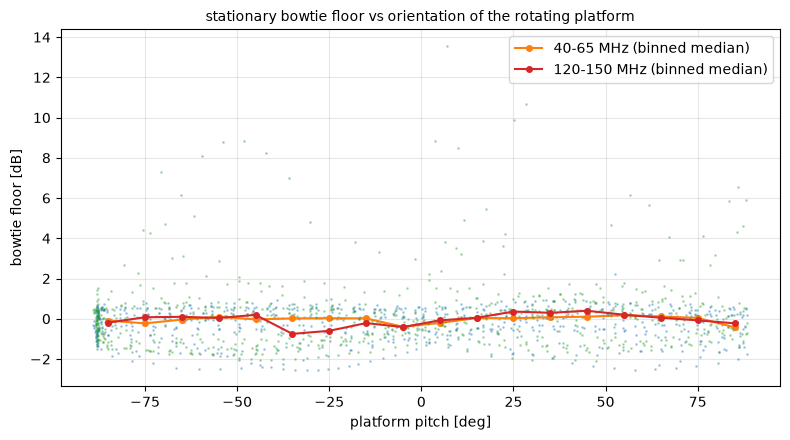

In [15]:
# binned floor vs platform pitch, raster interval only
ras = (times_r >= datetime(2025, 7, 19, 13, 5, 30, tzinfo=MTN).timestamp()) & \
      (times_r <= datetime(2025, 7, 19, 13, 19, 0, tzinfo=MTN).timestamp()) & ant_r
fig, ax = plt.subplots(figsize=(8, 4.5))
edges = np.arange(-90, 95, 10)
ctr = 0.5 * (edges[:-1] + edges[1:])
for bb, lbl in [(band1, "40-65 MHz"), (band2, "120-150 MHz")]:
    ts = np.nanmean(np.where(ant_r[:, None], data_r["2"], np.nan)[:, bb], axis=1)
    with np.errstate(all="ignore"):
        y = 10 * np.log10(ts / np.nanmedian(ts[ras]))
    ax.plot(pitch_i[ras], y[ras], ".", ms=2, alpha=0.3)
    med = [np.nanmedian(y[ras & (pitch_i >= e0) & (pitch_i < e1)]) for e0, e1 in zip(edges[:-1], edges[1:])]
    ax.plot(ctr, med, "-o", ms=4, label=f"{lbl} (binned median)")
    print(f"bowtie {lbl}: peak-to-peak modulation with pitch {np.nanmax(med) - np.nanmin(med):.1f} dB")
ax.set_xlabel("platform pitch [deg]")
ax.set_ylabel("bowtie floor [dB]")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("stationary bowtie floor vs orientation of the rotating platform", fontsize=10)
plt.tight_layout()
plt.show()

**Figure 6.** The same floor binned against platform pitch, in two bands. The response is
roughly symmetric about zero pitch, as a radiation or shadowing pattern would be. The
binned medians understate the swing seen in Figure 5 because the modulation is not a
function of pitch alone — averaging over everything else flattens it.

## What was measured

| Quantity | Value |
|---|---|
| Event shape | square, flat-bottomed, 1–3 dB |
| Band affected | broadband, ~30–160 MHz |
| Duration | ~240 s, tightly clustered |
| Cadence | 91 events over the deployment; median OFF 233 s |
| Floor present | **88 % of observing time** (fraction of antenna-state integrations outside an event) |
| — same thing, other bases | 94.6 % of the raw record span; 83.8 % of a cycle period. Section 9 prints all three and says what each counts |
| Extent | day and night, entire 5-day deployment |
| Level on bowtie (40–150 MHz) | ~7–11 % of total measured power |
| Peak level | ~40 % (40–65 MHz), ~25 % (110–150 MHz) |
| Rig state during all 19 by-eye events | stationary (both IMUs frozen) |
| Comb through events | stable to ±0.1 dB |
| Narrowband lines through events | no consistent change |
| Floor modulation over pitch raster | up to ~1.5 dB, synchronous with sweeps |
| 244 MHz line over raster | drops ~3 dB, oscillates, snaps back at park |
| Gain-free emitter/comb ratio (Fig. 7) | see figure — larger on the ground antennas above 70 MHz |
| On-platform thermal controller | never ran (Section 9) |

The dropouts are the off-windows of something that is otherwise always on. That makes
them useful beyond the anomaly itself: they give an in-situ, antenna-referenced
measurement of the floor with no extra hardware, because the emitter provides its own
off-state.

**Not established here.** Where the emitter is. Figure 4 is a within-antenna fraction
and cannot localise; Figure 7 is gain-free and points at the ground antennas above
70 MHz, which is the opposite of what an on-platform source would give. The pitch
raster does not separate the cases either — the metal platform 40 cm below the antenna
shadows a ground source about as effectively as it would carry an on-board one.

**Open follow-ups.** A per-subsystem power-cycling audit at the next deployment is the
only thing that would identify the device. The 2026 comparison is in
`notebooks/christian/selfrfi_2025_2026/`.

## Figure 7 — emitter power referenced to the received comb

Figure 4 gave the floor as a fraction of each antenna's own power, which cannot be
compared between antennas. This is the comparison that can be.

The calibration comb is radiated from the **ground** transmitter and arrives at every
antenna. Taking the ratio of emitter power to received comb power cancels each
receiver's gain and bandpass, leaving a dimensionless number that means the same thing
at every antenna.

How to read it: a source sitting beside the comb transmitter gives a ratio that is the
same everywhere. A source on the suspended platform gives a much **larger** ratio on
the bowtie. A source nearer the ground antennas gives a larger ratio on those.

(Folded in from `localise_selfrfi.py`, which printed this as a table.)

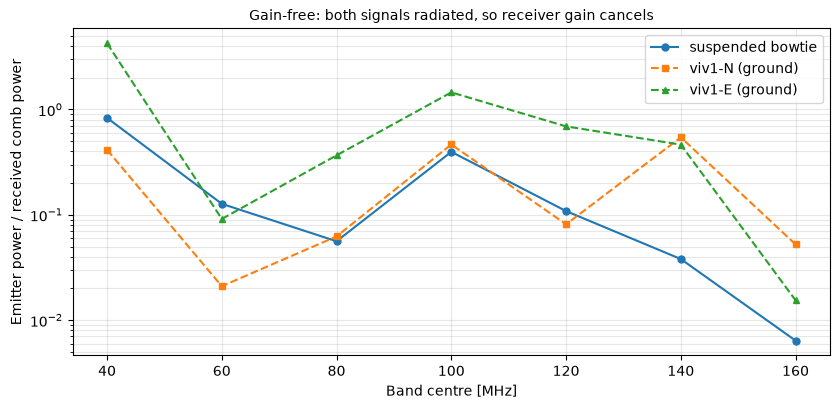

  band [MHz]    bowtie    viv1-N    viv1-E   larger on
   30-50         0.833     0.414     4.260   ambiguous
   50-70         0.127     0.021     0.091   ambiguous
   70-90         0.056     0.062     0.367   ground
   90-110        0.396     0.465     1.454   ambiguous
  110-130        0.109     0.081     0.692   ground
  130-150        0.038     0.544     0.464   ground
  150-170        0.006     0.052     0.015   ground

  40-65 MHz: bowtie/ground = 3.98x
  100-150 MHz: bowtie/ground = 0.13x
  30-160 MHz: bowtie/ground = 0.26x

  Same statistic for the 244 MHz line (radiated_selfRFI_lines.ipynb):
  bowtie 0.0017, viv1-E 1.14, viv1-N 0.26


In [16]:
# Gain-free localisation: emitter power / received comb power, per antenna.
# Uses the per-event stacks already loaded into S_IN/S_OUT/C_IN/C_OUT above.
ANTS_L = ["bowtie", "ground", "3"]
LBL_L = {"bowtie": "suspended bowtie", "ground": "viv1-N (ground)", "3": "viv1-E (ground)"}
comb_b = np.arange(nchan) % 16 == 0          # deployment-4 comb sits on residue 0
nontx_b = ~comb_b
ok_L = {p: (C_IN[p].min(axis=1) >= 50) & (C_OUT[p].min(axis=1) >= 100) for p in ANTS_L}

emitter_L, combpow_L = {}, {}
for p in ANTS_L:
    on = np.nanmedian(S_OUT[p][ok_L[p]] / C_OUT[p][ok_L[p]], axis=0)
    off = np.nanmedian(S_IN[p][ok_L[p]] / C_IN[p][ok_L[p]], axis=0)
    emitter_L[p] = on - off
    # comb power = comb channel minus the mean of its non-comb neighbours
    cont = np.array([np.nanmean(on[max(0, c - 6):c + 7][nontx_b[max(0, c - 6):c + 7]])
                     for c in np.nonzero(comb_b)[0]])
    combpow_L[p] = on[comb_b] - cont
comb_idx_L = np.nonzero(comb_b)[0]


def ratio_L(p, f0, f1):
    b = nontx_b & (freq >= f0) & (freq < f1)
    sel = (freq[comb_idx_L] >= f0) & (freq[comb_idx_L] < f1)
    pc = np.nansum(combpow_L[p][sel])
    return np.nansum(emitter_L[p][b]) / pc if pc > 0 else np.nan


bands_L = [(f0, f0 + 20) for f0 in range(30, 170, 20)]
ctr_L = [0.5 * (a + b) for a, b in bands_L]

plt.figure(figsize=(8.5, 4.2))
for p, mk in zip(ANTS_L, ["o-", "s--", "^--"]):
    plt.plot(ctr_L, [ratio_L(p, a, b) for a, b in bands_L], mk, ms=5, label=LBL_L[p])
plt.yscale("log")
plt.xlabel("Band centre [MHz]")
plt.ylabel("Emitter power / received comb power")
plt.title("Gain-free: both signals radiated, so receiver gain cancels", fontsize=10)
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"{'band [MHz]':>12} {'bowtie':>9} {'viv1-N':>9} {'viv1-E':>9}   larger on")
for f0, f1 in bands_L:
    r = {p: ratio_L(p, f0, f1) for p in ANTS_L}
    g = np.nanmean([r["ground"], r["3"]])
    v = ("platform" if r["bowtie"] > 3 * g
         else ("ground" if g > 3 * r["bowtie"] else "ambiguous"))
    print(f"{f0:5d}-{f1:<6d} {r['bowtie']:9.3f} {r['ground']:9.3f} {r['3']:9.3f}   {v}")
print()
for f0, f1 in [(40, 65), (100, 150), (30, 160)]:
    r = {p: ratio_L(p, f0, f1) for p in ANTS_L}
    g = np.nanmean([r["ground"], r["3"]])
    print(f"  {f0}-{f1} MHz: bowtie/ground = {r['bowtie'] / g:.2f}x")
print("\n  Same statistic for the 244 MHz line (radiated_selfRFI_lines.ipynb):")
print("  bowtie 0.0017, viv1-E 1.14, viv1-N 0.26")

**Figure 7.** Emitter power divided by received comb power, in 20 MHz bands, for the
suspended bowtie and the two polarisations of the ground Vivaldi. Log scale. Because
both quantities are radiated signals measured by the same receiver, the ratio is
independent of that receiver's gain and bandpass, so the three traces are directly
comparable in a way Figure 4's are not.

Below ~70 MHz the bowtie ratio is comparable to the ground antennas'. Above it, the
ground antennas run higher. The printed table gives the per-band verdict and the
bowtie/ground ratio in three wider bands.

This is the measurement that does not agree with reading Figure 4's spread as
geometry. Both are in the notebook; they measure different things.

## Figure 8 — duty-cycle timing

The events repeat. Whether the interval is fixed or varies with time of day
distinguishes two kinds of source: a digital scheduler gives a tight, time-of-day
invariant period, while a thermostatic load cycles faster when there is more heat to
shed.

The census is recomputed at several detrend-window lengths, because the measured
interval could otherwise be an artefact of the 35-minute window used for Figure 3.

(Folded in from `localise_selfrfi.py`.)

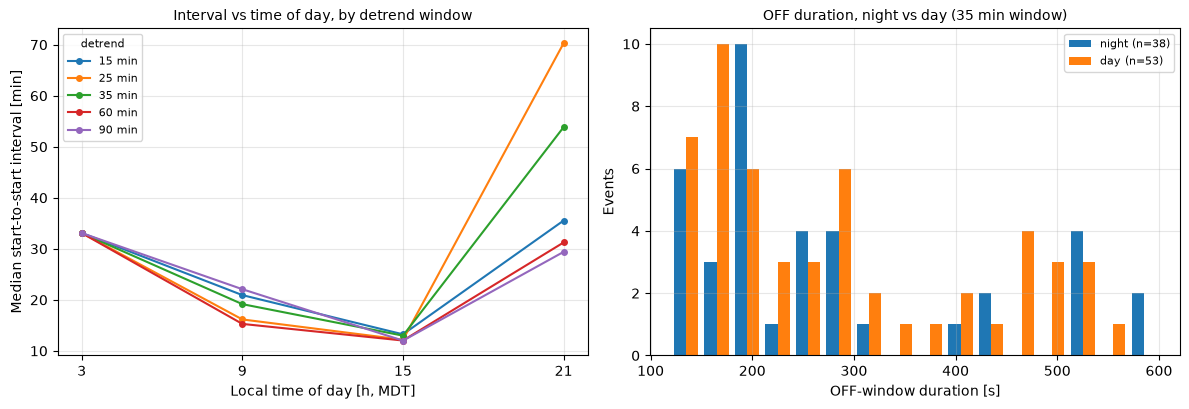

Night only (20:30-09:30 MDT), 35 min detrend window:
  20:30-24:00  n= 5  median interval  63.4 min
  00:00-03:00  n= 6  median interval  50.1 min
  03:00-06:00  n=11  median interval  26.3 min
  06:00-09:30  n=12  median interval  24.6 min

OFF duration while the interval varies:
  night  median 221 s  IQR [181, 307]
  day    median 242 s  IQR [169, 394]


In [17]:
# Duty-cycle timing: interval between events vs local time, at several detrend windows.
ant_T = antenna_mask(times_c, sw_t, sw_s)
bow_T = np.where(times_c < SWAP, bow4, bow2).astype(float)
bow_T[~ant_T] = np.nan
good_T = np.isfinite(bow_T)
fi_T = np.interp(times_c, times_c[good_T], bow_T[good_T])


def census_T(win_min, thr=-0.7):
    base = median_filter(fi_T, size=int(win_min * 60 / 1.07), mode="nearest")
    with np.errstate(all="ignore"):
        r = 10 * np.log10(fi_T / base)
    r[~good_T] = np.nan
    low = np.nan_to_num(r) < thr
    d = np.diff(low.astype(int))
    st, en = np.nonzero(d == 1)[0] + 1, np.nonzero(d == -1)[0] + 1
    runs = []
    for s, e in zip(st, en):
        if runs and times_c[s] - times_c[runs[-1][1]] < 120:
            runs[-1][1] = e
        else:
            runs.append([s, e])
    return np.array([(times_c[s], times_c[e] - times_c[s])
                     for s, e in runs if 120 < times_c[e] - times_c[s] < 600])


def hours_T(ts):
    return np.array([datetime.fromtimestamp(t, MTN).hour
                     + datetime.fromtimestamp(t, MTN).minute / 60 for t in ts])


WINDOWS = (15, 25, 35, 60, 90)
BINS = [(0, 6), (6, 12), (12, 18), (18, 24)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.2))

for win in WINDOWS:
    ev = census_T(win)
    h, g = hours_T(ev[:, 0])[:-1], np.diff(ev[:, 0]) / 60.0
    sel = g < 120
    xs, ys = [], []
    for h0, h1 in BINS:
        k = sel & (h >= h0) & (h < h1)
        if k.sum() > 2:
            xs.append(0.5 * (h0 + h1)); ys.append(np.median(g[k]))
    axA.plot(xs, ys, "o-", ms=4, label=f"{win} min")
axA.set_xlabel("Local time of day [h, MDT]")
axA.set_ylabel("Median start-to-start interval [min]")
axA.set_title("Interval vs time of day, by detrend window", fontsize=10)
axA.set_xticks([3, 9, 15, 21])
axA.legend(fontsize=8, title="detrend", title_fontsize=8)
axA.grid(alpha=0.3)

ev35 = census_T(35)
h35 = hours_T(ev35[:, 0])
night_T = (h35 >= 20.5) | (h35 <= 9.5)
axB.hist([ev35[night_T, 1], ev35[~night_T, 1]], bins=np.linspace(120, 600, 17),
         label=[f"night (n={night_T.sum()})", f"day (n={(~night_T).sum()})"])
axB.set_xlabel("OFF-window duration [s]")
axB.set_ylabel("Events")
axB.set_title("OFF duration, night vs day (35 min window)", fontsize=10)
axB.legend(fontsize=8)
axB.grid(alpha=0.3)
plt.tight_layout()
plt.show()

g35 = np.diff(ev35[:, 0]) / 60.0
sel35 = g35 < 120
print("Night only (20:30-09:30 MDT), 35 min detrend window:")
for lo, hi, lbl in [(20.5, 24, "20:30-24:00"), (0, 3, "00:00-03:00"),
                    (3, 6, "03:00-06:00"), (6, 9.5, "06:00-09:30")]:
    k = sel35 & (h35[:-1] >= lo) & (h35[:-1] < hi)
    if k.sum() > 1:
        print(f"  {lbl}  n={k.sum():2d}  median interval {np.median(g35[k]):5.1f} min")
print("\nOFF duration while the interval varies:")
for lbl, k in [("night", night_T), ("day  ", ~night_T)]:
    print(f"  {lbl}  median {np.median(ev35[k, 1]):3.0f} s  "
          f"IQR [{np.percentile(ev35[k, 1], 25):.0f}, {np.percentile(ev35[k, 1], 75):.0f}]")

**Figure 8.** Left: median start-to-start interval against local time of day, computed
at five detrend-window lengths. The window changes how many marginal events are
detected but not the shape of the curve, so the time-of-day structure is not an
artefact of the 35-minute choice used elsewhere. Right: distribution of OFF-window
duration, night against day.

The interval varies with time of day while the OFF duration stays near constant. A
fixed digital schedule would hold both fixed.

## 9. Subsystem telemetry, and a reproduction check

Two housekeeping questions, printed rather than plotted: what the on-platform thermal
controller was doing, and whether the census reproduces from the caches alone.

The reproduction check is the part of `verify_selfrfi.py` worth keeping in the
notebook. It re-derives the headline quantities from the cached arrays only, so the
numbers quoted in the summary can be checked without the 30 GB of raw files. Its scope
is the **reduction**, not the raw read — the caches were built from the raw files and
are taken as given here.

In [18]:
# ---- on-platform thermal controller -----------------------------------------
print("on-platform thermal controller")
print(f"  {len(tc_t)} reports, columns [A_drive, A_active, B_drive, B_active]")
print(f"  unique rows        : {np.unique(tc_v, axis=0).tolist()}")
print(f"  value changes      : {np.count_nonzero(np.any(np.diff(tc_v, axis=0) != 0, axis=1))}")
print("  -> the controller never ran during the deployment")
print(f"\n  motor stream: {len(mot_t)} record(s) -> no motor power-state telemetry")

# ---- reproduction check from the caches alone -------------------------------
ARP_CHECK = [(t0, t1 - t0) for t0, t1 in ARP_DROPOUTS]
ev_v = census_T(35)
print("\n" + "-" * 66)
print("reproduction check (caches only)")
print("-" * 66)
print(f"  integrations         : {len(times_c)}")
print(f"  detected events      : {len(ev_v)}")
rec = sum(any(abs(t0 - e0) < 300 for e0, _ in ev_v) for t0, _ in ARP_CHECK)
print(f"  recall vs arp's list : {rec} of {len(ARP_CHECK)}")
# Two different bases -- they answer different questions, so report both.
off_frac = ev_v[:, 1].sum() / (times_c[-1] - times_c[0])
print(f"  median OFF duration  : {np.median(ev_v[:, 1]):.0f} s")
print(f"  OFF / record span    : {100 * off_frac:.1f} %  -> floor present "
      f"{100 * (1 - off_frac):.1f} % of the record")
print("      (the span includes stretches with no data and any period in which")
print("       the emitter was not cycling, so this is a lower bound on OFF)")
_g = np.diff(ev_v[:, 0]) / 60.0
_g = _g[_g < 120]
_duty = np.median(ev_v[:, 1]) / (np.median(_g) * 60.0)
print(f"  OFF / cycle interval : {100 * _duty:.1f} %  -> floor present "
      f"{100 * (1 - _duty):.1f} % while cycling")
print(f"      (median interval {np.median(_g):.0f} min; the interval varies ~2.5x")
print("       with time of day, Figure 8, so this varies with it)")

# The defensible duty cycle: fraction of ANTENNA-STATE time inside an event.
# Excludes calibration/load states and stretches with no data, which is what
# makes it differ from the record-span number above.
_in_ev = np.zeros(len(times_c), bool)
for _row in events:
    _in_ev |= (times_c >= _row[0]) & (times_c <= _row[0] + _row[1])
_sh = np.array([datetime.fromtimestamp(t, MTN).hour
                + datetime.fromtimestamp(t, MTN).minute / 60 for t in times_c])
_snight = (_sh >= 20.5) | (_sh <= 9.5)
_duty_ant = _in_ev[ant_T].mean()
_duty_ngt = _in_ev[ant_T & _snight].mean()
print(f"  OFF / antenna-state  : {100 * _duty_ant:.1f} % overall, "
      f"{100 * _duty_ngt:.1f} % at night")
print(f"      -> floor present {100 * (1 - _duty_ant):.0f} % of observing time."
      " This is the")
print("       number to quote: it counts only integrations actually on sky.")

# census detail, and a staleness check on the passB cache
from collections import Counter as _Counter
_per_day = _Counter(datetime.fromtimestamp(t, MTN).strftime("%a %m-%d")
                    for t in events[:, 0])
print(f"\n  events per day       : {dict(sorted(_per_day.items(), key=lambda kv: kv[0][4:]))}")
print(f"  night / work hours   : {int(is_night.sum())} / {int((~is_night).sum())}")
if events.shape[1] > 2:
    print(f"  median depth         : {np.nanmedian(events[:, 2]):.2f} dB")
_nE_cached = S_IN["bowtie"].shape[0]
if _nE_cached == int(is_night.sum()):
    print(f"  passB cache          : CONSISTENT ({_nE_cached} night events)")
else:
    print(f"  passB cache          : *** STALE -- cache has {_nE_cached}, "
          f"this census gives {int(is_night.sum())} ***")
for f0, f1 in [(40, 65), (100, 150)]:
    b = nontx_b & (freq >= f0) & (freq < f1)
    fr = 1 - (S_IN["bowtie"] / C_IN["bowtie"]) / (S_OUT["bowtie"] / C_OUT["bowtie"])
    print(f"  bowtie floor {f0}-{f1} MHz : "
          f"{100 * np.nanmedian(np.nanmedian(fr[ok_L['bowtie']], axis=0)[b]):.1f} % of total power")

on-platform thermal controller
  172462 reports, columns [A_drive, A_active, B_drive, B_active]


  unique rows        : [[0.0, 0.0, 0.0, 0.0]]
  value changes      : 0
  -> the controller never ran during the deployment

  motor stream: 1 record(s) -> no motor power-state telemetry

------------------------------------------------------------------
reproduction check (caches only)
------------------------------------------------------------------
  integrations         : 206325
  detected events      : 91
  recall vs arp's list : 15 of 19
  median OFF duration  : 233 s
  OFF / record span    : 5.4 %  -> floor present 94.6 % of the record
      (the span includes stretches with no data and any period in which
       the emitter was not cycling, so this is a lower bound on OFF)
  OFF / cycle interval : 16.2 %  -> floor present 83.8 % while cycling
      (median interval 24 min; the interval varies ~2.5x
       with time of day, Figure 8, so this varies with it)


  OFF / antenna-state  : 12.1 % overall, 10.7 % at night
      -> floor present 88 % of observing time. This is the
       number to quote: it counts only integrations actually on sky.

  events per day       : {'Thu 07-17': 11, 'Fri 07-18': 28, 'Sat 07-19': 23, 'Sun 07-20': 29}
  night / work hours   : 38 / 53
  median depth         : -1.12 dB
  passB cache          : CONSISTENT (38 night events)
  bowtie floor 40-65 MHz : 6.8 % of total power
  bowtie floor 100-150 MHz : 10.6 % of total power
